# Performance Deep-Dive: Memory Hierarchy & Core Stall Analysis
### Modern Architectural Analysis of 16 Data Structures

**Objective**: This notebook analyzes the impact of memory layout, allocator locality, and traversal complexity on modern CPU performance metrics.

### Why do I see 80 rows instead of 160?
In your raw CSV, each measurement was split across **2 physical lines** (due to a newline in the previous script). 
This notebook **automatically repairs and merges** those lines into 80 logical measurements (16 Data Structures × 5 N-sizes). Every bit of data is captured.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Modern GitHub Dark Aesthetics ──────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22', 
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e', 
    'text.color': '#e6edf3', 'grid.color': '#21262d',
    'font.family': 'monospace', 'axes.titlesize': 15,
    'legend.frameon': True, 'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d'
})

COLORS = {
    'Vector': '#79c0ff', 'Array': '#1f6feb', 'Deque': '#a5d6ff', 'Sequential': '#79c0ff',
    'BST': '#ff7b72', 'RBTree': '#ff9e44', 'BTree': '#f0883e', 'SkipList': '#d2a8ff', 'vEBTree': '#bc8cff',
    'LinkedList': '#f78166', 'SlabList': '#ffa198',
    'AoS': '#3fb950', 'SoA': '#56d364',
    'HashMap': '#e3b341', 'Trie': '#f8e3a1', 'CircularBuffer': '#388bfd'
}

def load_data(path):
    with open(path) as f:
        raw_lines = [l.strip() for l in f if l.strip()]
    
    header = raw_lines[0].split(',')
    cleaned_rows = []
    
    i = 1
    while i < len(raw_lines):
        parts = raw_lines[i].split(',')
        
        # Handle split records (legacy CSV format with trailing newlines)
        if len(parts) < 11 and i + 1 < len(raw_lines):
            cont = raw_lines[i+1].split(',')
            # Shift logic: field 9 is often duplicated in the legacy CSV
            full_parts = parts[:8] + [cont[0]] + cont[2:]
            i += 1
        else:
            full_parts = parts
            
        if len(full_parts) >= 11:
            row = dict(zip(header, full_parts[:11]))
            cleaned_rows.append(row)
        i += 1
        
    df = pd.DataFrame(cleaned_rows)
    df = df.replace('<not counted>', np.nan)
    for col in df.columns: 
        if col != 'data_structure': df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # Standardise Labels
    df = df[df['data_structure'].isin(COLORS.keys())]
    
    df['cycles_per_elem'] = df['cycles'] / df['N']
    df['cm_rate'] = df['cache_misses'] / df['N']
    df['br_miss_pct'] = (df['branch_misses'] / df['branches']) * 100
    
    return df.dropna(subset=['cycles', 'N'])

df = load_data('deep_scaling_results.csv')
print(f"Parsed {len(df)} logical records for {df['data_structure'].nunique()} structures.")
df.head()

Parsed 75 logical records for 15 structures.


,data_structure,N,runs,cycles,instructions,ipc,cache_misses,branches,branch_misses,L1_misses,TLB_misses,cycles_per_elem,cm_rate,br_miss_pct
0,Array,1000,30,3070576,3216177,1.05,58667,593174,20687,48242.0,NaN,3070.576000,58.667000,3.487510
1,Array,10000,30,4228499,4298573,1.02,37810,829488,72511,9574.0,NaN,422.849900,3.781000,8.741658
2,Array,100000,30,23911215,19409553,0.81,139355,3930279,620203,86574.0,164.0,239.112150,1.393550,15.780127
3,Array,1000000,30,241717558,160646171,0.66,828648,38692090,7948281,968967.0,5760.0,241.717558,0.828648,20.542393
4,Array,10000000,30,2781144124,1905089260,0.69,12977192,437465313,96205827,11510711.0,102433.0,278.114412,1.297719,21.991647


## 1 · Scaling Behavior (log-log)
Visualizes absolute performance growth across scales.

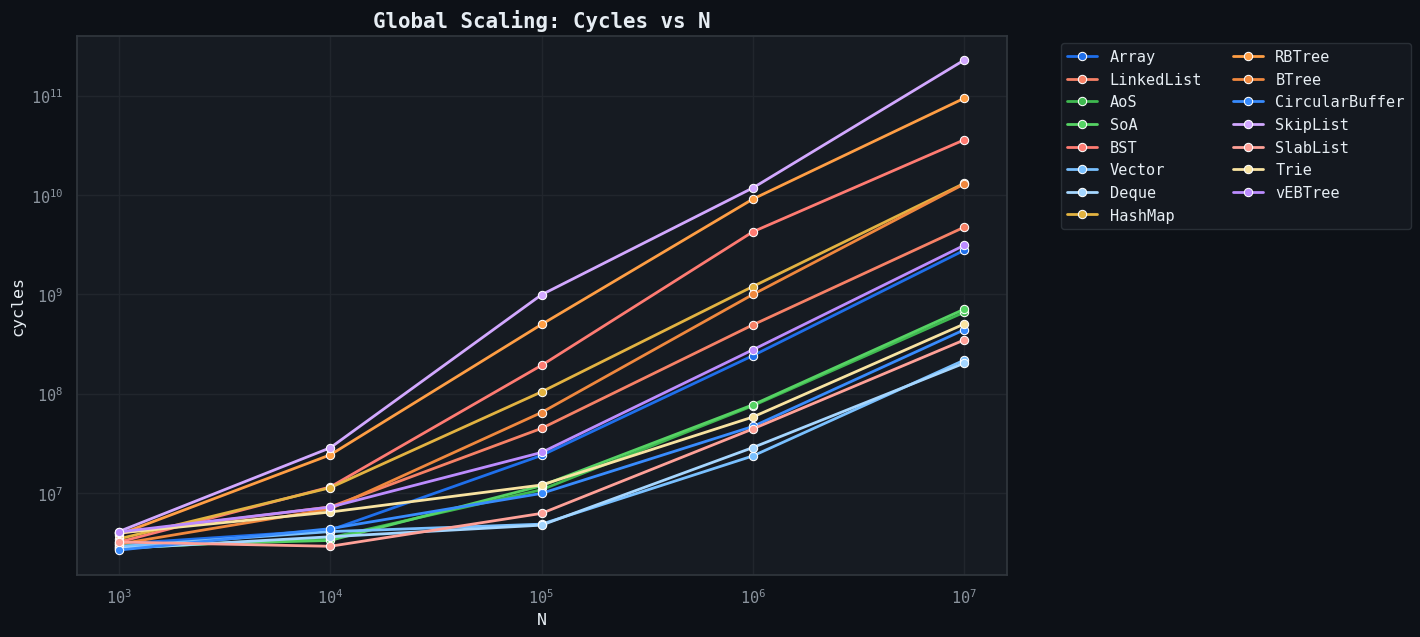

In [2]:
plt.figure(figsize=(12, 7))
palette = [COLORS.get(x, '#8b949e') for x in df['data_structure'].unique()]
sns.lineplot(data=df, x='N', y='cycles', hue='data_structure', palette=palette, marker='o', lw=2)
plt.xscale('log'); plt.yscale('log')
plt.title("Global Scaling: Cycles vs N", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.show()

## 2 · Efficiency Profiler (Cycles per Element)

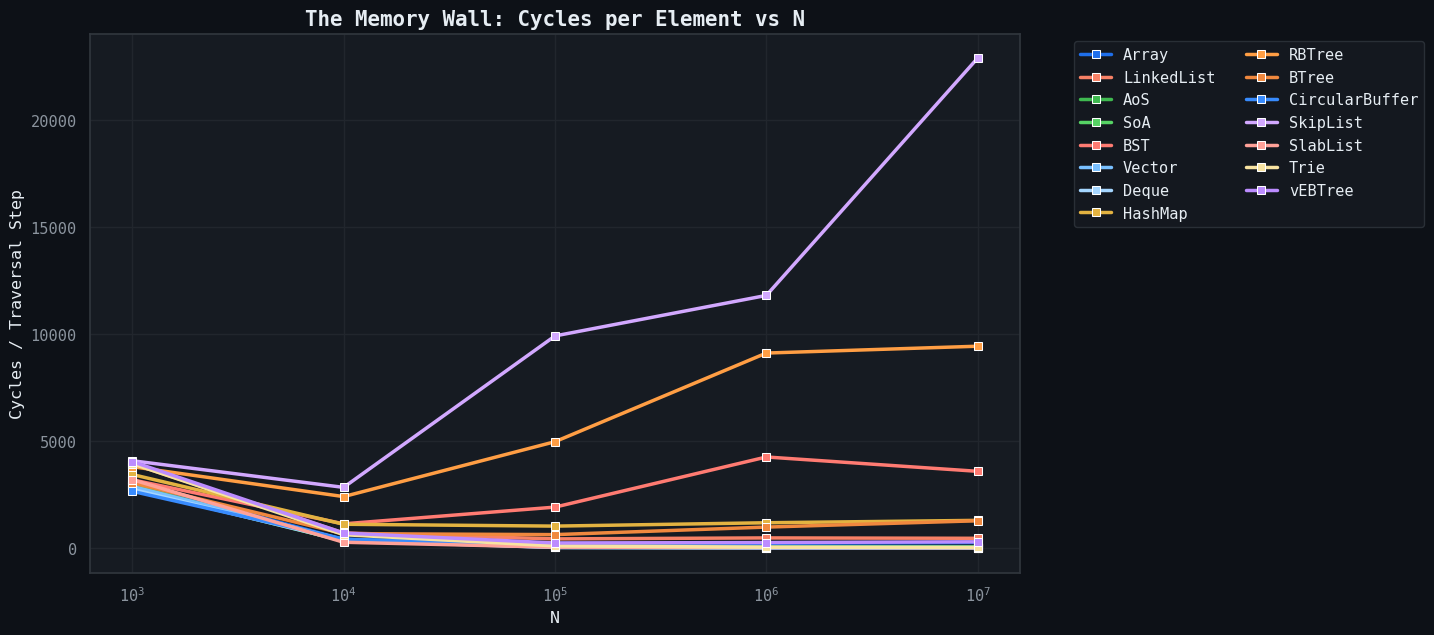

In [3]:
plt.figure(figsize=(12, 7))
palette = [COLORS.get(x, '#8b949e') for x in df['data_structure'].unique()]
sns.lineplot(data=df, x='N', y='cycles_per_elem', hue='data_structure', palette=palette, marker='s', lw=2.5)
plt.xscale('log')
plt.title("The Memory Wall: Cycles per Element vs N", fontweight='bold')
plt.ylabel("Cycles / Traversal Step")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.show()

## 3 · Bottleneck Identification: IPC vs Memory Stalls

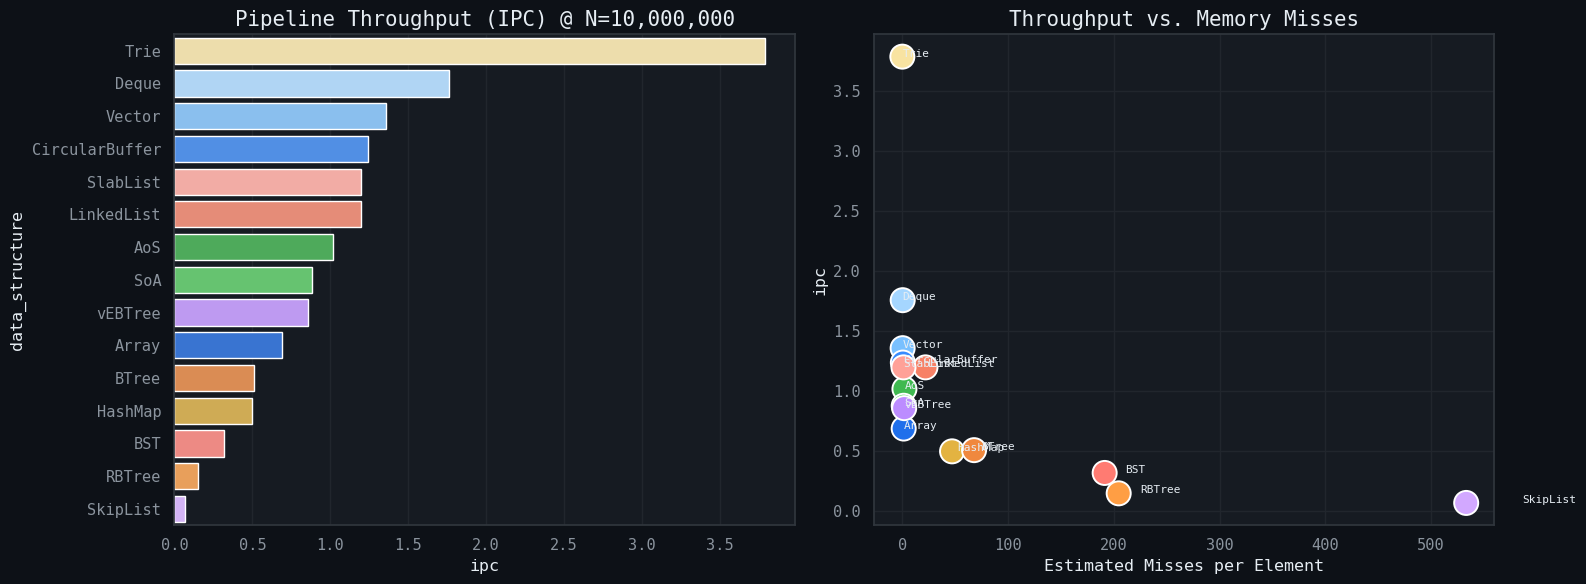

In [4]:
n_max = df['N'].max()
latest = df[df['N'] == n_max]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
latest_sorted = latest.sort_values('ipc', ascending=False)

sns.barplot(data=latest_sorted, x='ipc', y='data_structure', 
            palette=[COLORS.get(x, '#8b949e') for x in latest_sorted['data_structure']], ax=ax1)
ax1.set_title(f"Pipeline Throughput (IPC) @ N={n_max:,}")

palette_latest = [COLORS.get(x, '#8b949e') for x in latest['data_structure'].unique()]
sns.scatterplot(data=latest, x='cm_rate', y='ipc', hue='data_structure', 
                palette=palette_latest, s=300, ax=ax2, legend=False)
for i in range(latest.shape[0]):
    ax2.text(latest.cm_rate.iloc[i]*1.1, latest.ipc.iloc[i], latest.data_structure.iloc[i], fontsize=8)
ax2.set_title("Throughput vs. Memory Misses")
ax2.set_xlabel("Estimated Misses per Element")
plt.tight_layout()
plt.show()

## 4 · Head-to-Head Comparisons

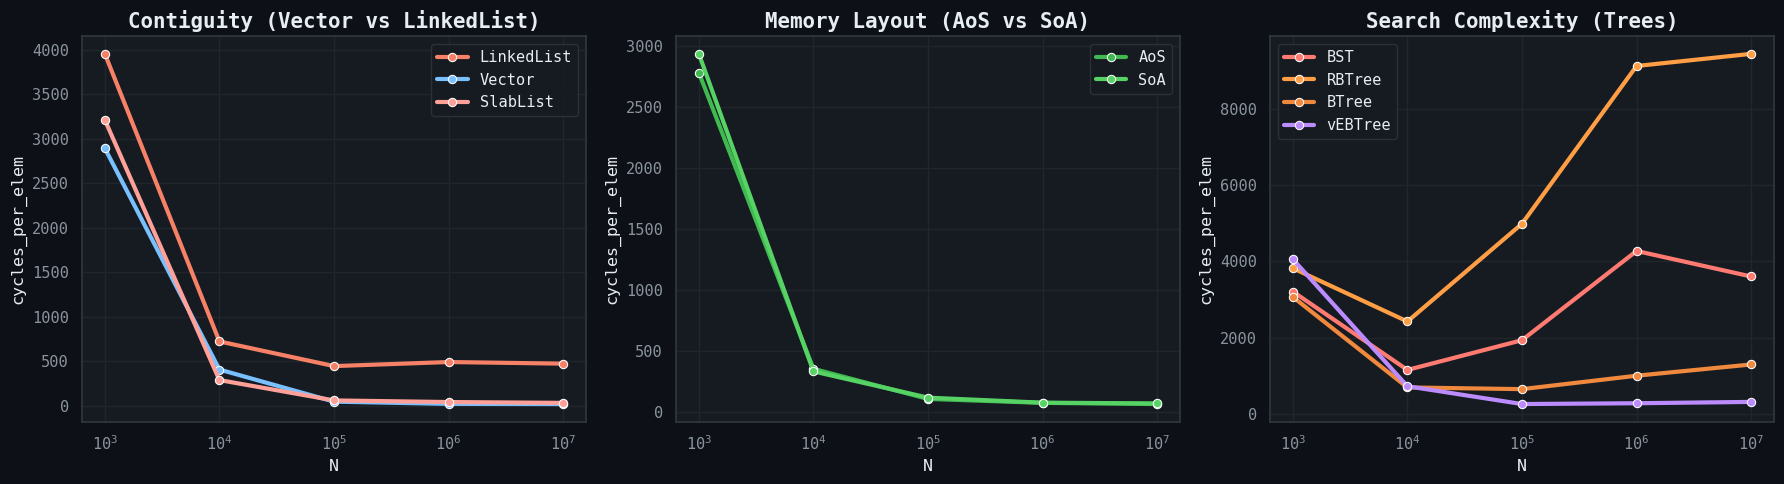

In [5]:
groups = {
    "Contiguity (Vector vs LinkedList)": ["Vector", "LinkedList", "SlabList"],
    "Memory Layout (AoS vs SoA)": ["AoS", "SoA"],
    "Search Complexity (Trees)": ["BST", "RBTree", "BTree", "vEBTree"]
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, names) in enumerate(groups.items()):
    target = df[df['data_structure'].isin(names)]
    pal = [COLORS.get(x, '#8b949e') for x in target['data_structure'].unique()]
    sns.lineplot(data=target, x='N', y='cycles_per_elem', hue='data_structure', 
                 palette=pal, marker='o', ax=axes[i], lw=3)
    axes[i].set_xscale('log'); axes[i].set_title(title, fontweight='bold'); axes[i].legend(title="")
plt.tight_layout()
plt.show()

## 5 · Performance Scorecard

In [6]:
scorecard = latest[['data_structure', 'cycles', 'ipc', 'cache_misses', 'br_miss_pct']].copy()
base_cycles = scorecard['cycles'].min()
scorecard['Relative_Cost'] = (scorecard['cycles'] / base_cycles).round(2)
scorecard = scorecard.sort_values('Relative_Cost')
scorecard.columns = ['Structure', 'Total Cycles', 'IPC', 'Cache Misses', 'Branch Miss %', 'Relative Cost (x)']

def color_cost(val):
    if val == 1.0: return 'color: #3fb950; font-weight: bold'
    if val > 10.0: return 'color: #ff7b72'
    return ''

try:
    styler = scorecard.style.map(color_cost, subset=['Relative Cost (x)'])
except AttributeError:
    styler = scorecard.style.applymap(color_cost, subset=['Relative Cost (x)'])
    
display(styler.format({
    'Total Cycles': "{:,}", 'IPC': "{:.2f}", 'Relative Cost (x)': "{:.2f}x"
}))

,Structure,Total Cycles,IPC,Cache Misses,Branch Miss %,Relative Cost (x)
34,Deque,"203,005,629",1.76,3499826,0.373779,1.00x
29,Vector,"217,800,988",1.36,2950207,0.073424,1.07x
69,SlabList,"347,839,179",1.20,10905251,0.103736,1.71x
59,CircularBuffer,"440,430,201",1.24,5017802,0.065171,2.17x
74,Trie,"503,360,669",3.79,293761,0.030464,2.48x
14,AoS,"661,100,953",1.02,20091208,0.101633,3.26x
19,SoA,"709,829,980",0.88,13172693,0.110202,3.50x
4,Array,"2,781,144,124",0.69,12977192,21.991647,13.70x
79,vEBTree,"3,119,520,641",0.86,17674741,20.864375,15.37x
9,LinkedList,"4,752,266,472",1.20,218714934,0.034329,23.41x
